In [2]:
##importing libraries

import pandas as pd               
import numpy as np                
import matplotlib.pyplot as plt   
import seaborn as sns             
import warnings
warnings.filterwarnings('ignore') 

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [3]:

# Load raw dataset
df = pd.read_csv(r'D:\projects\loan_default_prediction\data\raw\loan_default_risk_prediction_dataset(in).csv')

df_clean = df.copy()


checking current datatypes

In [4]:

dirty_columns = ['monthly_income', 'loan_amount', 'emi_amount',
                 'interest_rate', 'credit_card_usage', 
                 'debt_to_income_ratio', 'savings_ratio']

print("Current data types:")
print(df_clean[dirty_columns].dtypes)
print("\nSample values:")
print(df_clean[dirty_columns].head(3))

Current data types:
monthly_income          object
loan_amount             object
emi_amount              object
interest_rate           object
credit_card_usage       object
debt_to_income_ratio    object
savings_ratio           object
dtype: object

Sample values:
  monthly_income loan_amount emi_amount interest_rate credit_card_usage  \
0        ₹46,423  ₹1,275,865    ₹24,185        14.39%            29.16%   
1        ₹27,544    ₹663,459    ₹17,871        13.22%            17.30%   
2        ₹30,467    ₹472,681    ₹42,254        13.16%            79.63%   

  debt_to_income_ratio savings_ratio  
0               33.42%        85.57%  
1               58.51%        51.94%  
2               22.23%       -13.72%  


In [5]:


def clean_currency(value):
    
    if pd.isna(value):
        return np.nan
    
    
    value = value.replace('₹', '')
    
    value = value.replace(',', '')
    
    return float(value)

# Test
print(clean_currency('₹46,423'))     
print(clean_currency(np.nan))         

46423.0
nan


In [6]:
def clean_percent(value):
    
    if pd.isna(value):
        return np.nan
    
    
    value = value.replace('%', '')
    
    return float(value)

# Test
print(clean_percent('14.39%'))  
print(clean_percent(np.nan))       

14.39
nan


In [7]:
currency_cols = ['monthly_income', 'loan_amount', 'emi_amount']
percent_cols  = ['interest_rate', 'credit_card_usage',
                 'debt_to_income_ratio', 'savings_ratio']

for col in currency_cols:
    df_clean[col] = df_clean[col].apply(clean_currency)
    print(f"  ✓ Currency converted: {col}")


for col in percent_cols:
    df_clean[col] = df_clean[col].apply(clean_percent)
    print(f"  ✓ Percent converted: {col}")

print("\nAll conversions complete!")

  ✓ Currency converted: monthly_income
  ✓ Currency converted: loan_amount
  ✓ Currency converted: emi_amount
  ✓ Percent converted: interest_rate
  ✓ Percent converted: credit_card_usage
  ✓ Percent converted: debt_to_income_ratio
  ✓ Percent converted: savings_ratio

All conversions complete!


Conversion Check

In [8]:
# Check dtypes after conversion
print("Data types AFTER conversion:")
print(df_clean[dirty_columns].dtypes)

print("\nSample values:")
print(df_clean[dirty_columns].head())

Data types AFTER conversion:
monthly_income          float64
loan_amount             float64
emi_amount              float64
interest_rate           float64
credit_card_usage       float64
debt_to_income_ratio    float64
savings_ratio           float64
dtype: object

Sample values:
   monthly_income  loan_amount  emi_amount  interest_rate  credit_card_usage  \
0         46423.0    1275865.0     24185.0          14.39              29.16   
1         27544.0     663459.0     17871.0          13.22              17.30   
2         30467.0     472681.0     42254.0          13.16              79.63   
3         55866.0     665588.0     14372.0          15.82              61.28   
4       1625233.0    1503618.0     34289.0          13.10               0.00   

   debt_to_income_ratio  savings_ratio  
0                 33.42          85.57  
1                 58.51          51.94  
2                 22.23         -13.72  
3                 47.73          78.03  
4                 33.64        

Helper Funtion

In [9]:
#Fillilng Missing values
def missing_report(df):
    """Generate missing value summary for a DataFrame."""
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing': missing, 'Percent': pct})
    report = report[report['Missing'] > 0]
    report = report.sort_values('Percent', ascending=False)
    return report

In [10]:
print("Missing values BEFORE imputation:")
missing_report(df_clean)

Missing values BEFORE imputation:


,Missing,Percent
credit_score,2557,5.01
repayment_history_score,2548,5.00
employment_type,2541,4.98
loan_amount,2540,4.98
debt_to_income_ratio,2520,4.94
monthly_income,2513,4.93
bank_balance,2514,4.93


--All missing values has been filled

In [11]:
# Numeric columns to fill with median
numeric_to_impute = ['credit_score', 'repayment_history_score',
                     'debt_to_income_ratio', 'monthly_income',
                     'loan_amount', 'bank_balance']

for col in numeric_to_impute:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  - {col}: filled with median = {median_val:,.2f}")

  - credit_score: filled with median = 681.00
  - repayment_history_score: filled with median = 6.99
  - debt_to_income_ratio: filled with median = 38.23
  - monthly_income: filled with median = 55,319.00
  - loan_amount: filled with median = 707,310.50
  - bank_balance: filled with median = 86,161.50


In [12]:
#Categorical columns to fill with unknown

df_clean['employment_type'] = df_clean['employment_type'].fillna('Unknown')
print(f"employment_type: filled with 'Unknown'")

employment_type: filled with 'Unknown'


In [13]:
print("Missing values after imputation:")
print(missing_report(df_clean))
print(f"\nTotal missing cells remaining: {df_clean.isnull().sum().sum()}")

Missing values after imputation:
Empty DataFrame
Columns: [Missing, Percent]
Index: []

Total missing cells remaining: 0


Cleaning Duplicates

In [14]:
df_clean.duplicated().sum()


1000

In [15]:
df_clean =df_clean.drop_duplicates()

In [16]:
df_clean.duplicated().sum()


0

In [17]:

(df_clean['age'] < 18).sum() + (df_clean['age'] > 75).sum()

100

In [18]:
# Marking invalid ages as NaN
df_clean.loc[df_clean['age'] < 18, 'age'] = np.nan
df_clean.loc[df_clean['age'] > 75, 'age'] = np.nan

# Filling NaN with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

print("age min:", df_clean['age'].min())
print("age max:", df_clean['age'].max())

age min: 21.0
age max: 65.0


Checking credit score

In [19]:
((df_clean['credit_score'] < 300) | (df_clean['credit_score'] > 900)).sum()

100

In [20]:
#Marking invalid credit scores as NaN
df_clean.loc[df_clean['credit_score'] < 300, 'credit_score'] = np.nan
df_clean.loc[df_clean['credit_score'] > 900, 'credit_score'] = np.nan

# Filling NaN with median
df_clean['credit_score'] = df_clean['credit_score'].fillna(df_clean['credit_score'].median())

print("credit_score min:", df_clean['credit_score'].min())
print("credit_score max:", df_clean['credit_score'].max())

credit_score min: 318.0
credit_score max: 900.0


Fixing annual income

In [21]:
(df_clean['annual_income'] < 0).sum()

36

In [22]:
df_clean.loc[df_clean['annual_income'] < 0, 'annual_income'] = np.nan
df_clean['annual_income'] = df_clean['annual_income'].fillna(df_clean['annual_income'].median())

print("annual_income min:", df_clean['annual_income'].min())

annual_income min: 584.0


Fixing montly income

In [23]:
(df_clean['monthly_income'] < 0).sum()

100

In [24]:
df_clean.loc[df_clean['monthly_income'] < 0, 'monthly_income'] = np.nan
df_clean['monthly_income'] = df_clean['monthly_income'].fillna(df_clean['monthly_income'].median())

print("monthly_income min:", df_clean['monthly_income'].min())

monthly_income min: 8000.0


Fixing loan term months

In [25]:
(df_clean['loan_term_months'] < 1).sum()

100

In [26]:
df_clean.loc[df_clean['loan_term_months'] < 1, 'loan_term_months'] = np.nan
df_clean['loan_term_months'] = df_clean['loan_term_months'].fillna(df_clean['loan_term_months'].median())

print("loan_term_months min:", df_clean['loan_term_months'].min())

loan_term_months min: 12.0


Fixing loan amount

In [27]:
(df_clean['loan_amount'] <= 0).sum()

0

In [28]:
df_clean.loc[df_clean['loan_amount'] <= 0, 'loan_amount'] = np.nan
df_clean['loan_amount'] = df_clean['loan_amount'].fillna(df_clean['loan_amount'].median())

print("loan_amount min:", df_clean['loan_amount'].min())

loan_amount min: 50000.0


In [29]:
print("age:", df_clean['age'].min(), "to", df_clean['age'].max())
print("credit_score:", df_clean['credit_score'].min(), "to", df_clean['credit_score'].max())
print("annual_income min:", df_clean['annual_income'].min())
print("monthly_income min:", df_clean['monthly_income'].min())
print("loan_term_months min:", df_clean['loan_term_months'].min())
print("loan_amount min:", df_clean['loan_amount'].min())

age: 21.0 to 65.0
credit_score: 318.0 to 900.0
annual_income min: 584.0
monthly_income min: 8000.0
loan_term_months min: 12.0
loan_amount min: 50000.0


Visualize outliers

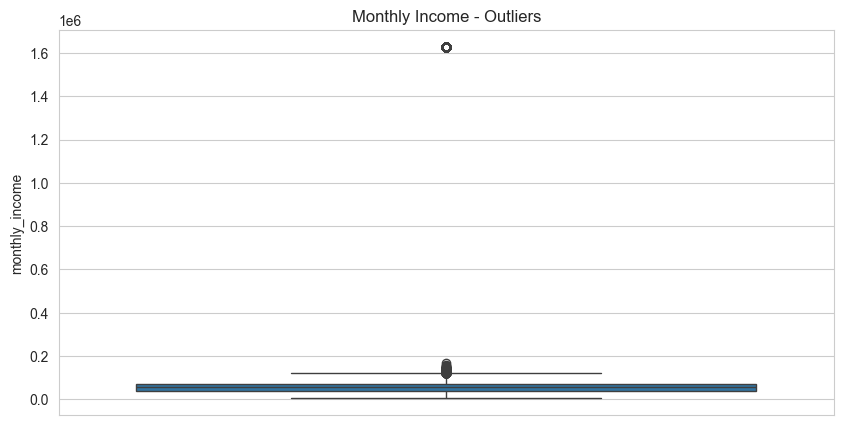

In [30]:
sns.boxplot(y=df_clean['monthly_income'])
plt.title('Monthly Income - Outliers')
plt.show()

In [31]:

#checking q1,q3 and iqr
Q1 = df_clean['monthly_income'].quantile(0.25)
Q3 = df_clean['monthly_income'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 39333.75
Q3: 71439.0
IQR: 32105.25


In [32]:
#calculating bound
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: -8824.125
Upper bound: 119596.875


Counting Outliers

In [34]:
(df_clean['monthly_income'] < lower).sum()

0

In [35]:
(df_clean['monthly_income'] > upper).sum()

745

In [36]:
df_clean['monthly_income'] = df_clean['monthly_income'].clip(lower=lower, upper=upper)
print("After capping:")
print("Min:", df_clean['monthly_income'].min())
print("Max:", df_clean['monthly_income'].max())

After capping:
Min: 8000.0
Max: 119596.875


Reusable funtion

In [37]:
def cap_outliers(col_name):
    Q1 = df_clean[col_name].quantile(0.25)
    Q3 = df_clean[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_capped = ((df_clean[col_name] < lower) | (df_clean[col_name] > upper)).sum()
    df_clean[col_name] = df_clean[col_name].clip(lower=lower, upper=upper)
    print(f"{col_name}: capped {n_capped} values")

In [38]:
cap_outliers('annual_income')

annual_income: capped 192 values


In [39]:
cap_outliers('loan_amount')
cap_outliers('emi_amount')
cap_outliers('bank_balance')
cap_outliers('savings_amount')
cap_outliers('monthly_expense')
cap_outliers('additional_income')

loan_amount: capped 739 values
emi_amount: capped 3111 values
bank_balance: capped 741 values
savings_amount: capped 210 values
monthly_expense: capped 184 values
additional_income: capped 191 values


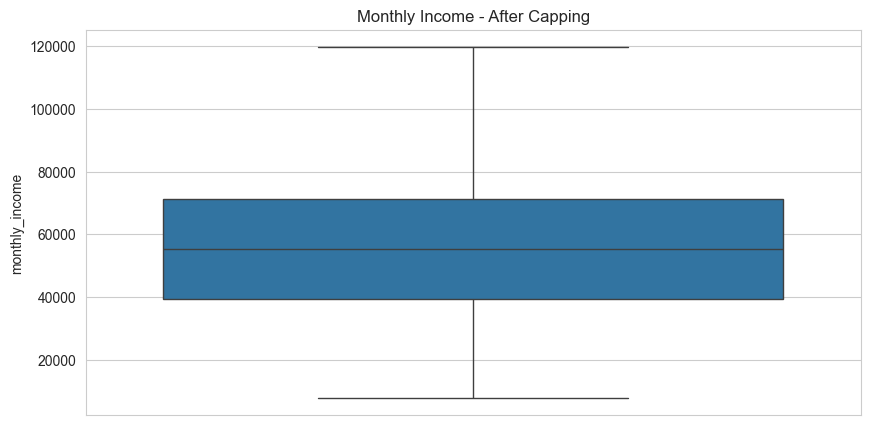

In [40]:
sns.boxplot(y=df_clean['monthly_income'])
plt.title('Monthly Income - After Capping')
plt.show()